In [4]:
import pandas as pd
import numpy as np
df=pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [5]:

##=============
#1.Data Understanding
#=================
df.info()
df.shape
df.describe()
print('\nFirst 5 rows:')
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
##missing
df.isna().sum()
df.isna().sum().sum()
missing = pd.DataFrame({
    'Total Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
missing = missing[missing['Total Missing'] > 0]
print("\n[Missing Values Summary]")
print(missing if not missing.empty else "No missing values found.")


[Missing Values Summary]
No missing values found.


In [7]:
##duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
##
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtype


dtype('float64')

In [9]:

# 4. 字段维度与基数划分 (Cardinality & Types)
target_col = 'Churn'
id_col = 'customerID'

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in [target_col, id_col]]

print("\n[Feature Types]")
print(f"Numerical Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

# 数值型字段统计（均值、分位数、偏度）
print('\n[Numerical Summary]')
num_summary=df[numeric_cols].describe().T[['mean','std','min','50%','max']]
num_summary['skew']=df[numeric_cols].skew()
print(num_summary)

# 类别型字段基数与唯一值检查
print("\n[Categorical Summary]")
cat_summary = pd.DataFrame({
    'Unique Values': df[categorical_cols].nunique(),
    'Sample Values': [df[c].unique().tolist()[:3] for c in categorical_cols]
})
print(cat_summary)


[Feature Types]
Numerical Features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

[Numerical Summary]
                       mean          std    min       50%      max      skew
SeniorCitizen      0.162147     0.368612   0.00     0.000     1.00  1.833633
tenure            32.371149    24.559481   0.00    29.000    72.00  0.239540
MonthlyCharges    64.761692    30.090047  18.25    70.350   118.75 -0.220524
TotalCharges    2283.300441  2266.771362  18.80  1397.475  8684.80  0.961642

[Categorical Summary]
                  Unique Values  \
gender                        2   
Partner                       2   
Dependents                    2   
PhoneService                  2   
MultipleLines             

In [10]:

##=============
#2.Data Preprocessing
#=================

y=(df['Churn']=='Yes').astype(int)
X=df.drop(columns=['customerID','Churn'])

In [11]:
##binary
binary_cols=['Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
    X[col]=(X[col]=='Yes').astype(int)

##multipleservices
service_cols=['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in service_cols:
    X[col]=(X[col]=='Yes').astype(int)

numeric_cols=['tenure','MonthlyCharges','TotalCharges']
multi_cat_cols=['gender','InternetService','Contract','PaymentMethod']


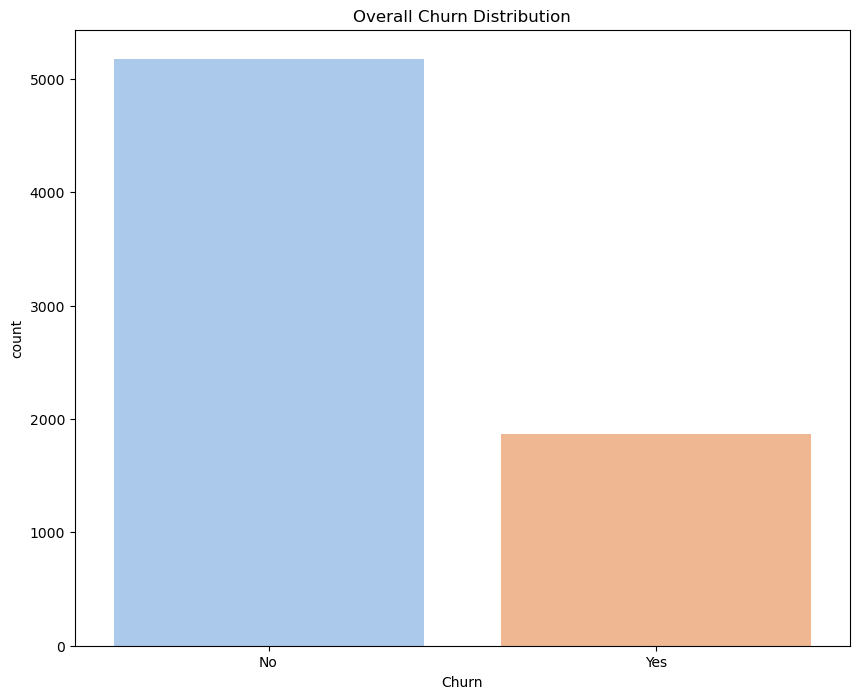

In [12]:
##=============
#3.EDA
#=================

import matplotlib.pyplot as plt
import seaborn as sns
##target distribution
plt.figure(figsize=(10,8))
sns.countplot(data=df,x='Churn',hue='Churn',palette='pastel',legend=False)
plt.title('Overall Churn Distribution')
plt.show()

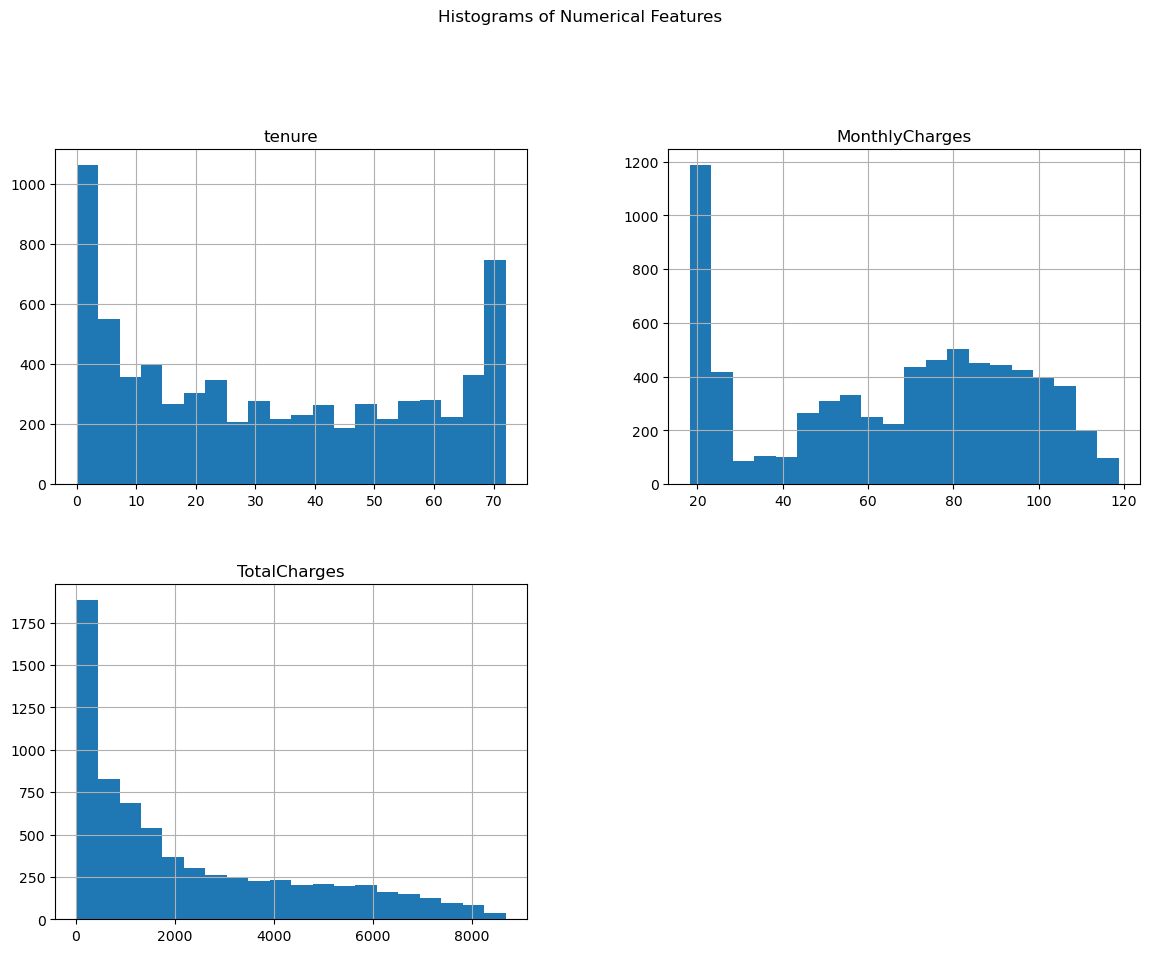

In [13]:
##histogram
df[numeric_cols].hist(figsize=(14,10),bins=20)
plt.suptitle('Histograms of Numerical Features',y=1.02)
plt.show()

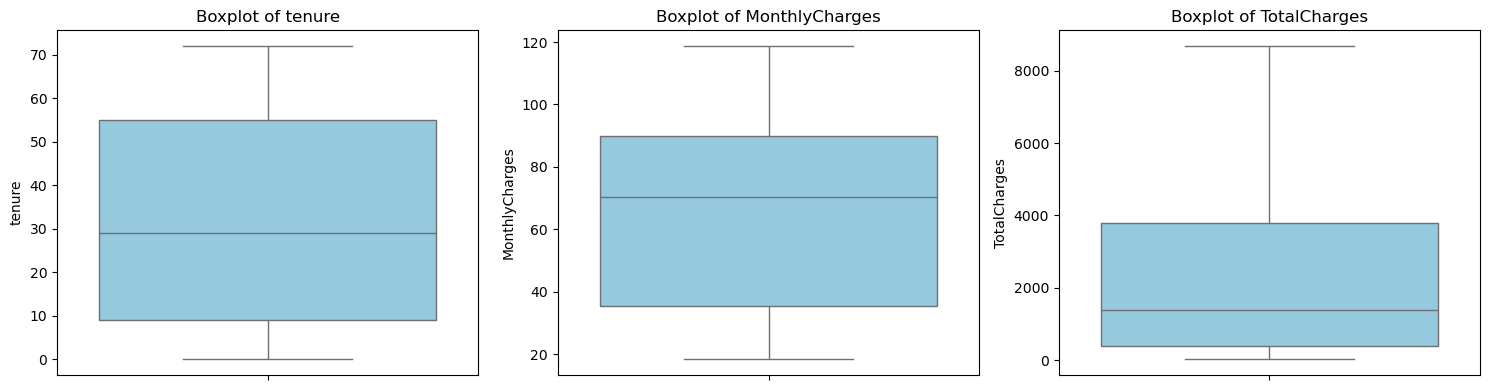

In [14]:
##boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

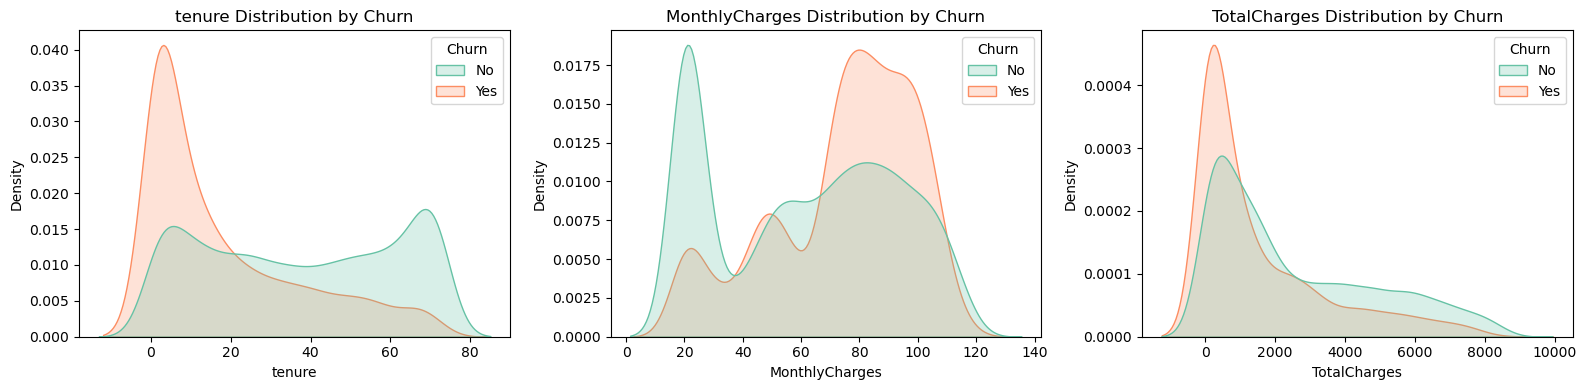

In [15]:
##Bivariate Analysis
# 2. 关键数值特征分布与流失关系 (tenure, MonthlyCharges, TotalCharges)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', common_norm=False, fill=True, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Distribution by Churn')
plt.tight_layout()
plt.show()


C:\Users\howeian\AppData\Local\Temp\ipykernel_41596\2836654142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churn_Rate', ax=axes[i], palette='Blues_d')
C:\Users\howeian\AppData\Local\Temp\ipykernel_41596\2836654142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churn_Rate', ax=axes[i], palette='Blues_d')
C:\Users\howeian\AppData\Local\Temp\ipykernel_41596\2836654142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=col, y='Churn_Rate', ax=axes[i], palette=

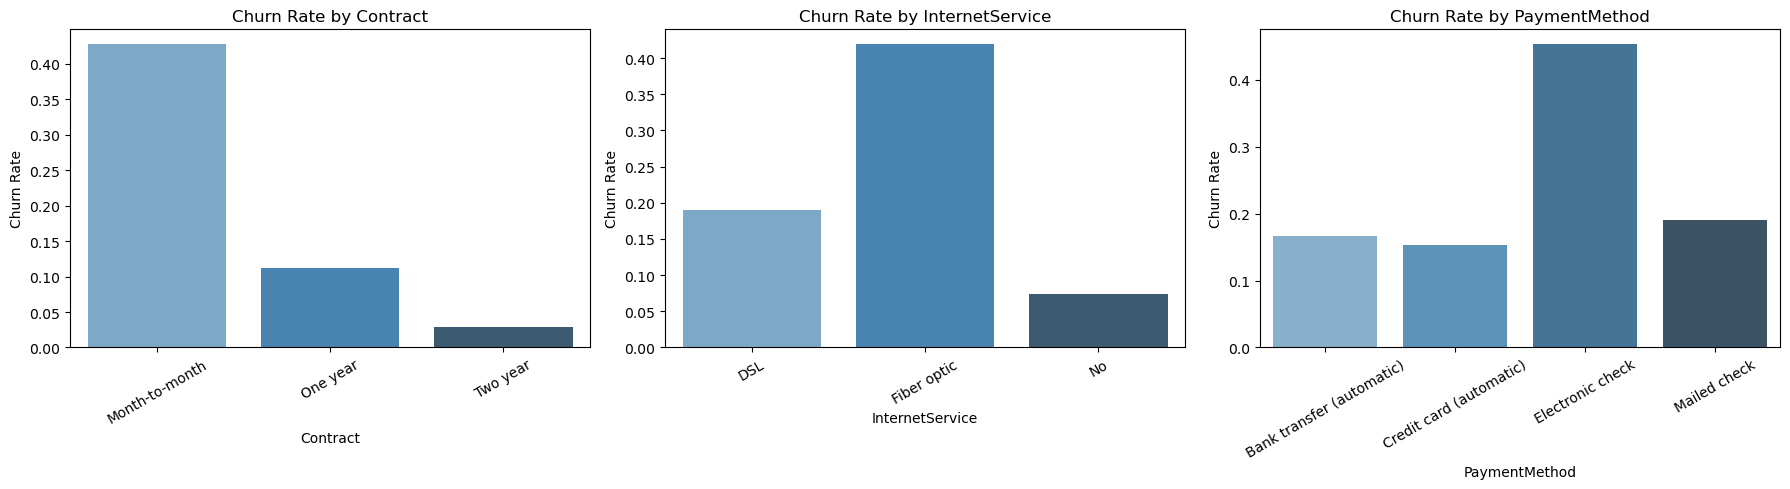

In [16]:
##categorical
cat_focus = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_focus):
    # 计算不同类别的流失率
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    
    sns.barplot(data=churn_rate, x=col, y='Churn_Rate', ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

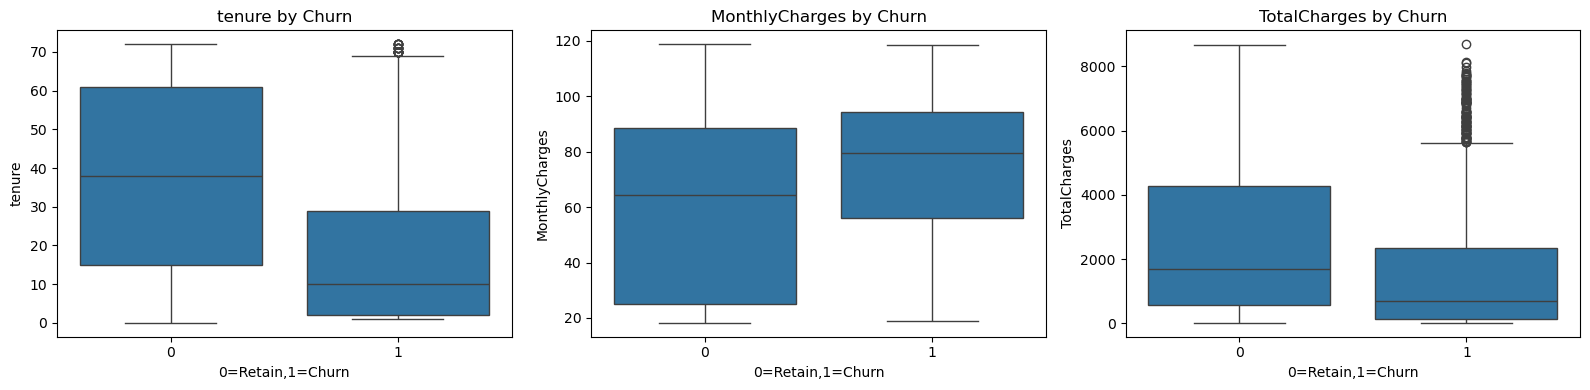

In [17]:
##bivariate boxplot
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes=axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(x=y,y=col,data=df,ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('0=Retain,1=Churn')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [18]:
##cleaning
# 1. Clean TotalCharges (if applicable) and drop non-informative ID columns
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 2. Encode Target and Binary features to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)

# 3. Simplify 3-category service features to binary 0/1
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   MultipleLines                          7043 non-null   int64  
 6   OnlineSecurity                         7043 non-null   int64  
 7   OnlineBackup                           7043 non-null   int64  
 8   DeviceProtection                       7043 non-null   int64  
 9   TechSupport                            7043 non-null   int64  
 10  StreamingTV                            7043 non-null   int64  
 11  Stre

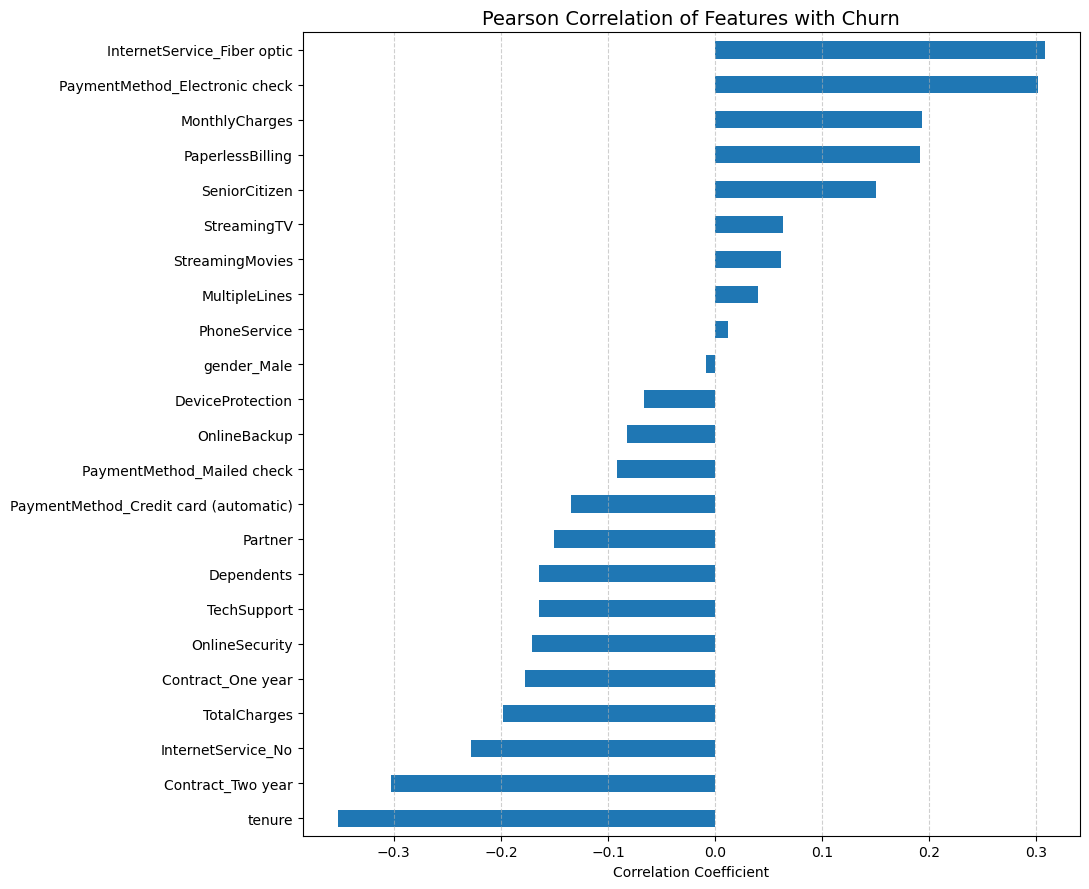

In [19]:
##multivariate analysis
##pearson
corr_matrix=df_encoded.corr()
target_corr=corr_matrix['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(11,9))
target_corr.plot(kind='barh',color='#1f77b4')
plt.title('Pearson Correlation of Features with Churn',fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


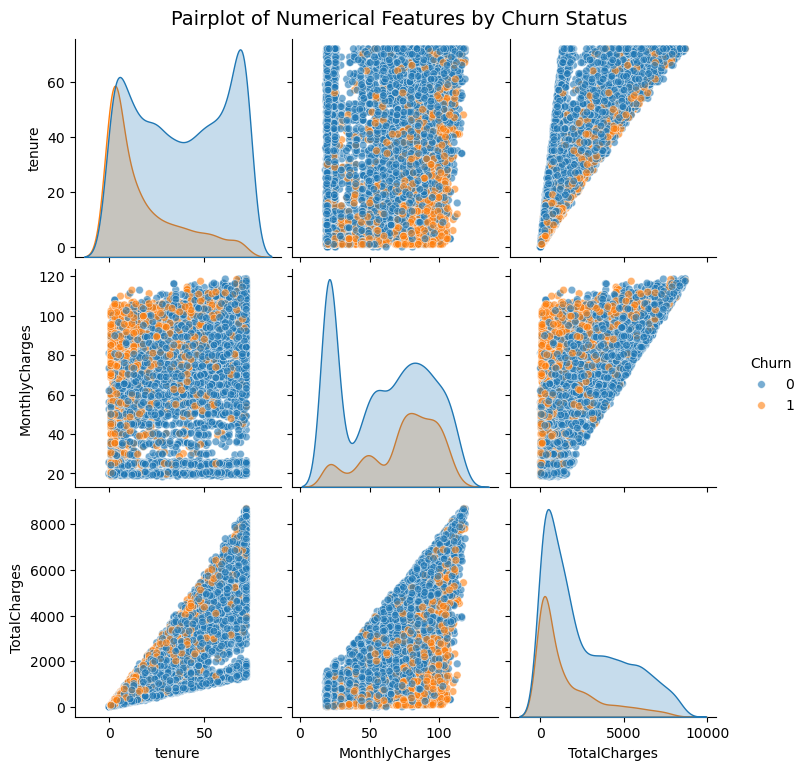

In [20]:
##pairplot
# Focus pairplot on continuous variables with Churn as hue
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

sns.pairplot(
    df[numerical_cols + ['Churn']], 
    hue='Churn', 
    palette={0: '#1f77b4', 1: '#ff7f0e'}, # 0: No Churn, 1: Churn
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02, fontsize=14)
plt.show()

In [21]:
target_corr

tenure                                  -0.352229
Contract_Two year                       -0.302253
InternetService_No                      -0.227890
TotalCharges                            -0.198324
Contract_One year                       -0.177820
OnlineSecurity                          -0.171226
TechSupport                             -0.164674
Dependents                              -0.164221
Partner                                 -0.150448
PaymentMethod_Credit card (automatic)   -0.134302
PaymentMethod_Mailed check              -0.091683
OnlineBackup                            -0.082255
DeviceProtection                        -0.066160
gender_Male                             -0.008612
PhoneService                             0.011942
MultipleLines                            0.040102
StreamingMovies                          0.061382
StreamingTV                              0.063228
SeniorCitizen                            0.150889
PaperlessBilling                         0.191825


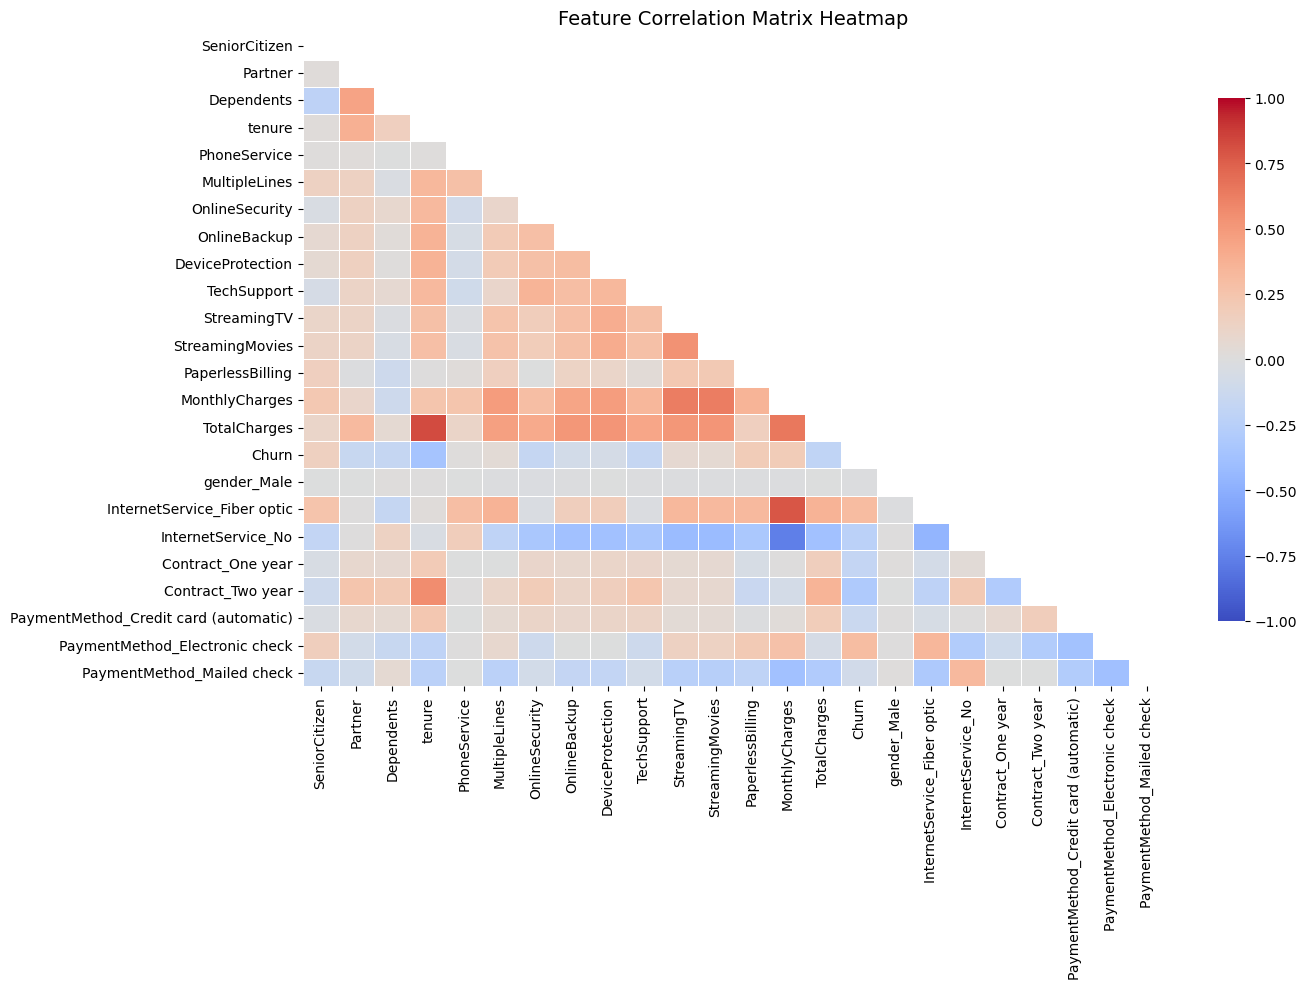

In [22]:
plt.figure(figsize=(14, 10))

# Compute correlation matrix
corr = df_encoded.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Draw heatmap
sns.heatmap(
    corr, 
    mask=mask,
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=False,  # Set to True if viewing a subset of features
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve

In [29]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,1,DSL,1,0,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,Female,0,1,1,72,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,Female,0,1,1,11,0,0,DSL,1,0,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,Male,1,1,0,4,1,1,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


In [30]:
# ==========================================
# 2. 特征工程 (Feature Engineering)
# ==========================================
# (1) 增值服务订阅总数 (Service Aggregation)
df['TotalServices'] = df[service_cols].sum(axis=1)

# (2) 平均每月实际花费 (Expected Monthly vs Actual)
df['AvgMonthlyCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

# (3) 短期资费异常比 (Monthly Charge Spike Ratio)
df['ChargeRatio'] = df['MonthlyCharges'] / (df['AvgMonthlyCharges'] + 1e-5)

In [31]:
# ==========================================
# 3. 特征降维与编码 (Feature Reduction & Encoding)
# ==========================================
df_reduced=df.drop(columns=['TotalCharges'])
df_model = pd.get_dummies(df_reduced, drop_first=True, dtype=int)
df_model

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,AvgMonthlyCharges,ChargeRatio,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,14.925000,1.999999,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,1,0,1,0,...,53.985714,1.054909,1,0,0,1,0,0,0,1
2,0,0,0,2,1,0,1,1,0,0,...,36.050000,1.493758,1,0,0,0,0,0,0,1
3,0,0,0,45,0,0,1,0,1,1,...,40.016304,1.057069,1,0,0,1,0,0,0,0
4,0,0,0,2,1,0,0,0,0,0,...,50.550000,1.398615,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,0,1,1,...,79.620000,1.065059,1,0,0,1,0,0,0,1
7039,0,1,1,72,1,1,0,1,1,0,...,100.861644,1.023184,0,1,0,1,0,1,0,0
7040,0,1,1,11,0,0,1,0,0,0,...,28.870833,1.025256,0,0,0,0,0,0,1,0
7041,1,1,0,4,1,1,0,0,0,0,...,61.320000,1.213307,1,1,0,0,0,0,0,1


In [32]:
X=df_model.drop(columns=['Churn'])
y=df_model['Churn']

In [36]:
# ==========================================
# 4. 数据划分与标准化 (Train/Test Split & Scaling)
# ==========================================
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [57]:
# ==========================================
# 3. Model Training (3 Iterations)
# ==========================================
models = {
    'Standard LR': LogisticRegression(penalty=None, max_iter=1000, random_state=42),
    'Ridge LR (L2)': LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=8, 
        min_samples_split=10, 
        class_weight='balanced', 
        random_state=42
    )
}

results = []
probs = {}

for name, model in models.items():
    # Trees don't strictly require scaling, but scaled data works identically
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_default = (y_prob >= 0.49).astype(int)
    
    probs[name] = y_prob
    report = classification_report(y_test, y_pred_default, output_dict=True)
    
    results.append({
        'Model': name,
        'Accuracy (Thresh=0.5)': report['accuracy'],
        'Recall (Churn=1)': report['1']['recall'],
        'Precision (Churn=1)': report['1']['precision'],
        'F1-Score (Churn=1)': report['1']['f1-score'],
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

print("=== Model Comparison at Default Threshold (0.50) ===")
print(pd.DataFrame(results).to_string(index=False))

=== Model Comparison at Default Threshold (0.50) ===
        Model  Accuracy (Thresh=0.5)  Recall (Churn=1)  Precision (Churn=1)  F1-Score (Churn=1)  ROC-AUC
  Standard LR               0.806246          0.532086             0.670034            0.593145 0.843468
Ridge LR (L2)               0.806246          0.542781             0.665574            0.597938 0.844925
Random Forest               0.765082          0.778075             0.539889            0.637459 0.846511


=== Model Comparison at Default Threshold (0.50) ===
        Model  Accuracy (Thresh=0.5)  Recall (Churn=1)  Precision (Churn=1)  F1-Score (Churn=1)  ROC-AUC
  Standard LR               0.806246          0.521390             0.674740            0.588235 0.843468
Ridge LR (L2)               0.808375          0.521390             0.681818            0.590909 0.844925
Random Forest               0.764372          0.767380             0.539474            0.633554 0.846511
  Standard LR               0.806246          0.521390             0.674740            0.588235 0.843468
Ridge LR (L2)               0.808375          0.521390             0.681818            0.590909 0.844925
Random Forest               0.764372          0.767380             0.539474            0.633554 0.846511
  Standard LR               0.772179          0.708556             0.555556            0.622797 0.843468
Ridge LR (L2)               0.776437          0.719251             0.561587            0.630715 0.844925
Ra

In [56]:
# ==========================================
# 4. Optimal Threshold Tuning (Example: Best Model)
# ==========================================
# Use predicted probabilities of the best performing model (e.g., Ridge LR or RF)
target_model_name = 'Random Forest'
y_prob_target = probs[target_model_name]

# Scan thresholds from 0.10 to 0.90
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []
recalls = []
precisions = []

for t in thresholds:
    preds = (y_prob_target >= t).astype(int)
    report_t = classification_report(y_test, preds, output_dict=True, zero_division=0)
    f1_scores.append(report_t['1']['f1-score'])
    recalls.append(report_t['1']['recall'])
    precisions.append(report_t['1']['precision'])

# Identify threshold maximizing F1
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"\nOptimal Threshold for {target_model_name} (Max F1): {best_thresh:.2f}")
print(f"Metrics at {best_thresh:.2f} -> Recall: {recalls[best_idx]:.3f}, Precision: {precisions[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")


Optimal Threshold for Random Forest (Max F1): 0.49
Metrics at 0.49 -> Recall: 0.778, Precision: 0.540, F1: 0.637


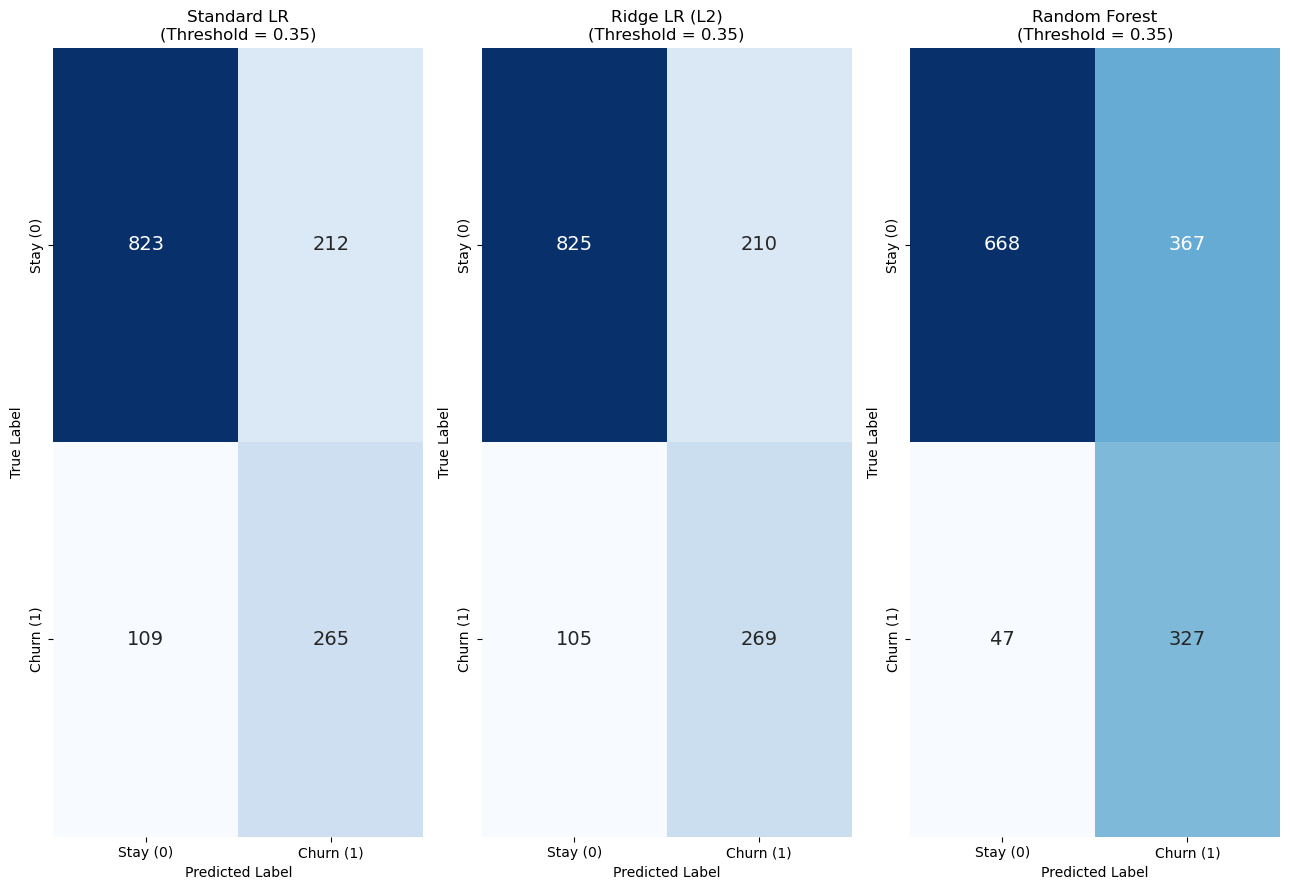

=== Performance Breakdown at Threshold = 0.35 ===
[Standard LR]
  Caught Churn (TP): 265 | Missed Churn (FN): 109
  False Alarms (FP): 212 | Correct Stay (TN): 823
  Recall: 70.86% | Precision: 55.56% | F1: 0.623

[Ridge LR (L2)]
  Caught Churn (TP): 269 | Missed Churn (FN): 105
  False Alarms (FP): 210 | Correct Stay (TN): 825
  Recall: 71.93% | Precision: 56.16% | F1: 0.631

[Random Forest]
  Caught Churn (TP): 327 | Missed Churn (FN): 47
  False Alarms (FP): 367 | Correct Stay (TN): 668
  Recall: 87.43% | Precision: 47.12% | F1: 0.612



In [52]:
thresholds=0.35

fig, axes = plt.subplots(1, len(models), figsize=(13, 9))

for idx, (name, model) in enumerate(models.items()):
        # Predict probabilities and apply threshold
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_prob >= thresholds).astype(int)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        ax = axes[idx]
        sns.heatmap(
            cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=False,
            ax=ax,
            annot_kws={"size": 14}
        )
        
        ax.set_title(f"{name}\n(Threshold = {thresholds})", fontsize=12)
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticklabels(['Stay (0)', 'Churn (1)'])
        ax.set_yticklabels(['Stay (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

# Print detailed quantitative numbers for easy reporting
print(f"=== Performance Breakdown at Threshold = {thresholds} ===")
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob >= thresholds).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"[{name}]")
    print(f"  Caught Churn (TP): {tp} | Missed Churn (FN): {fn}")
    print(f"  False Alarms (FP): {fp} | Correct Stay (TN): {tn}")
    print(f"  Recall: {recall:.2%} | Precision: {precision:.2%} | F1: {f1:.3f}\n")

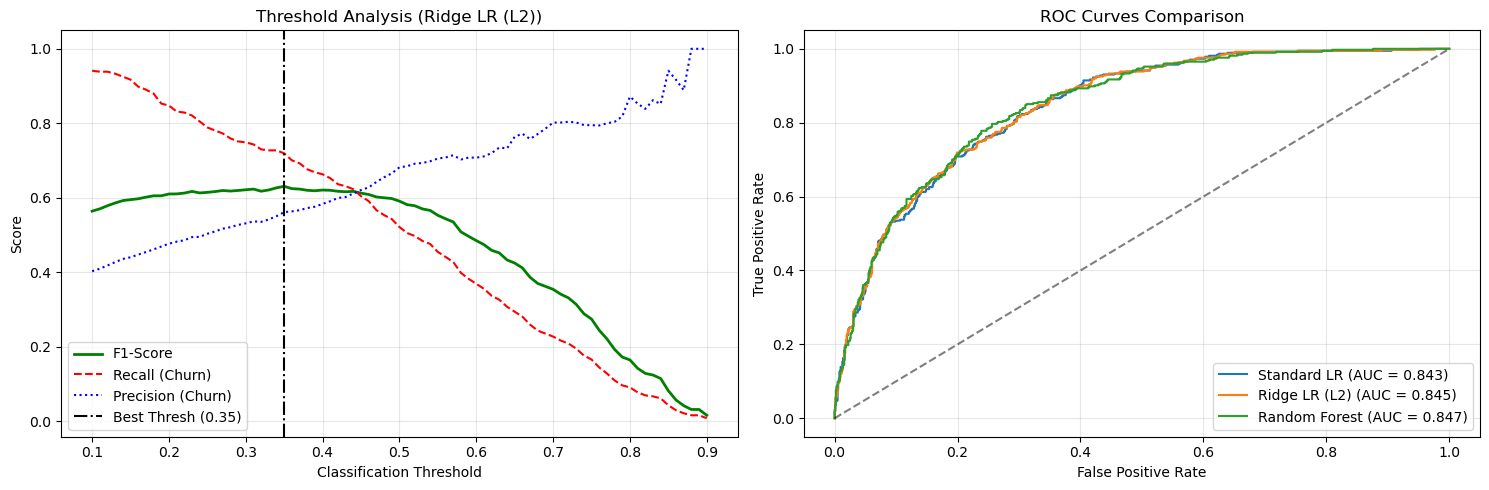

In [47]:
# ==========================================
# 5. Visualizing Threshold Trade-offs & ROC Curves
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Threshold Curve
axes[0].plot(thresholds, f1_scores, label='F1-Score', color='green', lw=2)
axes[0].plot(thresholds, recalls, label='Recall (Churn)', color='red', linestyle='--')
axes[0].plot(thresholds, precisions, label='Precision (Churn)', color='blue', linestyle=':')
axes[0].axvline(best_thresh, color='black', linestyle='-.', label=f'Best Thresh ({best_thresh:.2f})')
axes[0].set_title(f'Threshold Analysis ({target_model_name})')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: ROC Curves
for name, y_p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_p)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_p):.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curves Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 必须从刚才创建的 src 模块中导入函数
from src.preprocessing import engineer_features

# 1. 读取原始数据
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn'])

# 2. 先执行特征工程
X_engineered = engineer_features(X)

# 3. 确定输入特征类型
numeric_features = ['tenure', 'MonthlyCharges', 'TotalServices', 'AvgMonthlyCharges', 'ChargeRatio']
categorical_features = [col for col in X_engineered.columns if col not in numeric_features]

# 4. 组装纯净的标准 Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        max_depth=8, 
        min_samples_split=10, 
        class_weight='balanced', 
        random_state=42
    ))
])

# 5. 训练模型
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)
model_pipeline.fit(X_train, y_train)

# 6. 保存并覆盖 joblib 文件
os.makedirs('model', exist_ok=True)
joblib.dump(model_pipeline, 'model/churn_pipeline.joblib')
print("Model re-exported successfully!")

Model re-exported successfully!
